### Time Series forecasting

In [91]:
import pandas as pd
import numpy as np
from configs.system import project_dir

In [92]:
p_dir = project_dir()

data_dir = p_dir.FEATURED_DIR

dataset_path = data_dir/'featured_dataset.csv'

df = pd.read_csv(dataset_path,index_col=0)
df.head(3)

,UserID,ChargerID,ChargerCompany,Location,ChargerType,StartDay,StartTime,EndDay,EndTime,StartDatetime,...,Duration,Demand,StartMonth,StartWeek,EndMonth,EndWeek,DemandPerMonth,StartDayOfWeek,DemandPerDay,Shift
0,0,1,1,hotel,0,2022-09-15,20:54:02,2022-09-15,23:59:13,2022-09-15 20:54:00,...,185,20.36,9,3,9,3,111771.8,Thursday,17.62,Night
1,0,1,1,hotel,0,2022-09-14,20:01:05,2022-09-14,21:31:04,2022-09-14 20:01:00,...,90,10.19,9,2,9,2,111771.8,Wednesday,17.53,Night
2,0,1,1,hotel,0,2022-09-14,18:54:30,2022-09-14,19:54:29,2022-09-14 18:54:00,...,60,6.78,9,2,9,2,111771.8,Wednesday,17.53,Night


In [93]:
df.info()

<class 'pandas.DataFrame'>
Index: 72826 entries, 0 to 72855
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   UserID          72826 non-null  int64  
 1   ChargerID       72826 non-null  int64  
 2   ChargerCompany  72826 non-null  int64  
 3   Location        72826 non-null  str    
 4   ChargerType     72826 non-null  int64  
 5   StartDay        72826 non-null  str    
 6   StartTime       72826 non-null  str    
 7   EndDay          72826 non-null  str    
 8   EndTime         72826 non-null  str    
 9   StartDatetime   72826 non-null  str    
 10  EndDatetime     72826 non-null  str    
 11  Duration        72826 non-null  int64  
 12  Demand          72826 non-null  float64
 13  StartMonth      72826 non-null  int64  
 14  StartWeek       72826 non-null  int64  
 15  EndMonth        72826 non-null  int64  
 16  EndWeek         72826 non-null  int64  
 17  DemandPerMonth  72826 non-null  float64
 18  St

In [94]:
df.describe()

,UserID,ChargerID,ChargerCompany,ChargerType,Duration,Demand,StartMonth,StartWeek,EndMonth,EndWeek,DemandPerMonth,DemandPerDay
count,72826.000000,72826.000000,72826.000000,72826.000000,72826.000000,72826.000000,72826.000000,72826.000000,72826.000000,72826.000000,72826.000000,72826.000000
mean,337.978208,525.319172,0.627647,0.205009,151.222105,17.440366,6.244116,2.927430,6.243430,2.939953,110329.040585,17.440217
std,553.828304,569.513697,0.483435,0.403711,146.416111,13.490614,3.256757,1.952394,3.256181,1.953740,21702.528539,0.209140
min,0.000000,1.000000,0.000000,0.000000,0.000000,0.010000,1.000000,0.000000,1.000000,0.000000,64933.480000,17.100000
25%,0.000000,107.000000,0.000000,0.000000,40.000000,7.530000,4.000000,1.000000,4.000000,1.000000,103141.960000,17.310000
50%,61.000000,300.000000,1.000000,0.000000,112.000000,14.100000,6.000000,3.000000,6.000000,3.000000,109639.330000,17.410000
75%,407.000000,738.000000,1.000000,0.000000,202.000000,23.200000,9.000000,5.000000,9.000000,5.000000,117564.420000,17.620000
max,2501.000000,2671.000000,1.000000,1.000000,1573.000000,97.000000,12.000000,6.000000,12.000000,6.000000,143041.270000,17.810000


In [95]:
df.columns

Index(['UserID', 'ChargerID', 'ChargerCompany', 'Location', 'ChargerType',
       'StartDay', 'StartTime', 'EndDay', 'EndTime', 'StartDatetime',
       'EndDatetime', 'Duration', 'Demand', 'StartMonth', 'StartWeek',
       'EndMonth', 'EndWeek', 'DemandPerMonth', 'StartDayOfWeek',
       'DemandPerDay', 'Shift'],
      dtype='str')

In [96]:
df['StartDatetime'] = pd.to_datetime(df['StartDatetime'])
df['EndDatetime'] = pd.to_datetime(df['EndDatetime'])
df['StartDay'] = pd.to_datetime(df['StartDay'])
df['EndDay'] = pd.to_datetime(df['EndDay'])


In [97]:
df.info()

<class 'pandas.DataFrame'>
Index: 72826 entries, 0 to 72855
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   UserID          72826 non-null  int64         
 1   ChargerID       72826 non-null  int64         
 2   ChargerCompany  72826 non-null  int64         
 3   Location        72826 non-null  str           
 4   ChargerType     72826 non-null  int64         
 5   StartDay        72826 non-null  datetime64[us]
 6   StartTime       72826 non-null  str           
 7   EndDay          72826 non-null  datetime64[us]
 8   EndTime         72826 non-null  str           
 9   StartDatetime   72826 non-null  datetime64[us]
 10  EndDatetime     72826 non-null  datetime64[us]
 11  Duration        72826 non-null  int64         
 12  Demand          72826 non-null  float64       
 13  StartMonth      72826 non-null  int64         
 14  StartWeek       72826 non-null  int64         
 15  EndMonth        72

In [98]:
df.sample(3)

,UserID,ChargerID,ChargerCompany,Location,ChargerType,StartDay,StartTime,EndDay,EndTime,StartDatetime,...,Duration,Demand,StartMonth,StartWeek,EndMonth,EndWeek,DemandPerMonth,StartDayOfWeek,DemandPerDay,Shift
45494,209,458,0,public institution,1,2022-09-20,21:18:21,2022-09-20,21:19:50,2022-09-20 21:18:00,...,1,0.93,9,1,9,1,111771.80,Tuesday,17.10,Night
55135,499,761,0,market,1,2022-09-02,17:56:03,2022-09-02,18:28:43,2022-09-02 17:56:00,...,33,35.90,9,4,9,4,111771.80,Friday,17.31,Night
5153,0,22,1,hotel,0,2022-06-11,16:04:59,2022-06-11,18:53:05,2022-06-11 16:04:00,...,168,18.20,6,5,6,5,117564.42,Saturday,17.41,Night


In [99]:
df_ = df.groupby('StartDay')['Demand'].sum()

In [100]:
df_

StartDay
2021-09-30     579.19
2021-10-01    2467.59
2021-10-02    2087.75
2021-10-03    1928.25
2021-10-04    1768.66
               ...   
2022-09-26    3995.26
2022-09-27    4404.18
2022-09-28    3673.44
2022-09-29    4170.49
2022-09-30    3426.76
Name: Demand, Length: 366, dtype: float64

In [108]:
## Sorting the index 
df_ = df_.sort_index()

In [110]:
# df_.sample(3)
df_

StartDay
2021-09-30     579.19
2021-10-01    2467.59
2021-10-02    2087.75
2021-10-03    1928.25
2021-10-04    1768.66
               ...   
2022-09-26    3995.26
2022-09-27    4404.18
2022-09-28    3673.44
2022-09-29    4170.49
2022-09-30    3426.76
Name: Demand, Length: 366, dtype: float64

In [112]:
print(df_.index.max())
df_.index.min()

2022-09-30 00:00:00


Timestamp('2021-09-30 00:00:00')

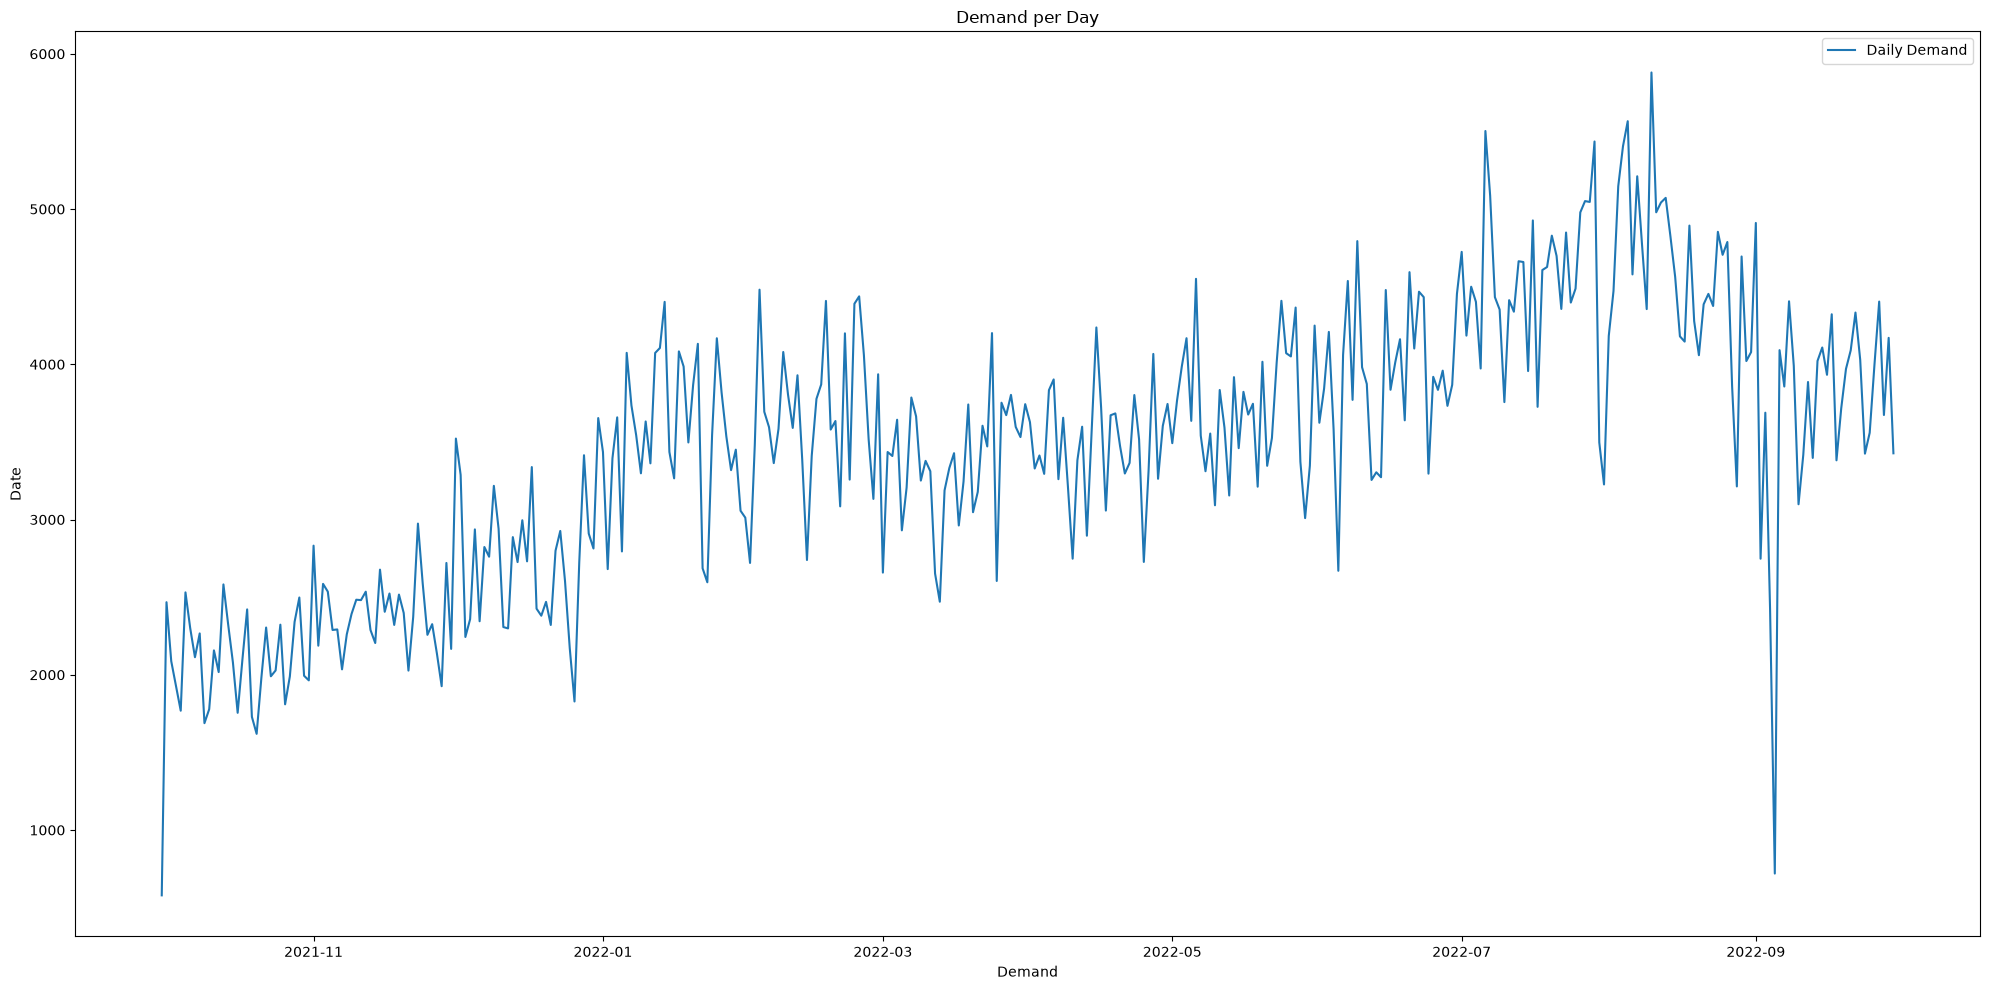

In [122]:
import matplotlib.pyplot as plt

plt.figure(figsize=(20,10))
plt.plot(df_.index,df_.values,linewidth=1.5,label='Daily Demand')
plt.title('Demand per Day')
plt.xlabel('Demand')
plt.ylabel('Date')
plt.legend()
plt.tight_layout()
plt.show()

In [129]:
from statsmodels.tsa.stattools import adfuller

results = adfuller(df_,result_object=True)
results

ADFullerResult
ADF Statistic: -1.88081
P-value: 0.34114
Used Lag: 13
Nobs: 352
Critical Values: {'1%': np.float64(-3.4490648539347544), '5%': np.float64(-2.8697861692116478), '10%': np.float64(-2.5711631253228306)}

In [132]:
## as the p-value of the results is morew than 0.05, which means the dataset is non-stationary. 

In [136]:
## splitting the dataset
train_size = int(len(df_) * 0.8)

train = df_[:train_size]
test = df_[train_size:]

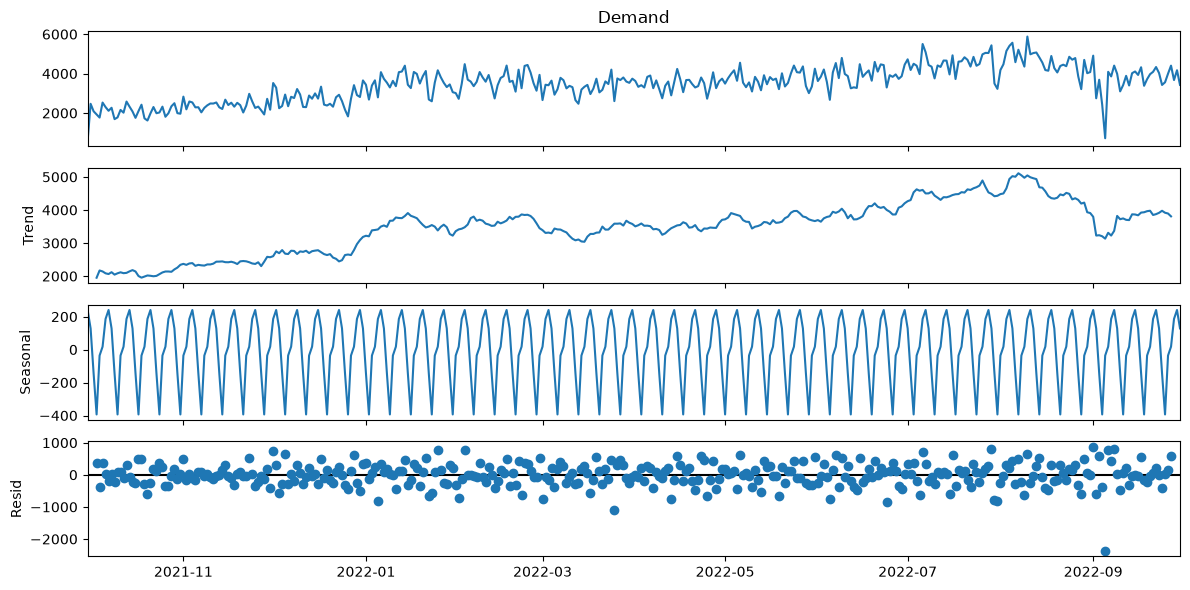

In [155]:
from statsmodels.tsa.seasonal import seasonal_decompose
results = seasonal_decompose(df_)
fig = results.plot()
fig.set_size_inches(12,6)
plt.tight_layout()
plt.show()

In [162]:
print(test.index.max())
test.index.min()

2022-09-30 00:00:00


Timestamp('2022-07-19 00:00:00')

In [158]:
## Calculating the 7 days moving avg

m_avg = train.iloc[-7:].mean()

moving_avg_forecast = pd.Series(m_avg,test.index)

In [159]:
moving_avg_forecast

StartDay
2022-07-19    4411.202857
2022-07-20    4411.202857
2022-07-21    4411.202857
2022-07-22    4411.202857
2022-07-23    4411.202857
                 ...     
2022-09-26    4411.202857
2022-09-27    4411.202857
2022-09-28    4411.202857
2022-09-29    4411.202857
2022-09-30    4411.202857
Length: 74, dtype: float64

In [171]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae = mean_absolute_error(test,moving_avg_forecast)
mae

mse = mean_squared_error(test,moving_avg_forecast)
mse

print(mae)

574.3496718146719


In [170]:
print(np.sqrt(mse))

795.2872988685037


### periods of increasing or decreasing charging demand

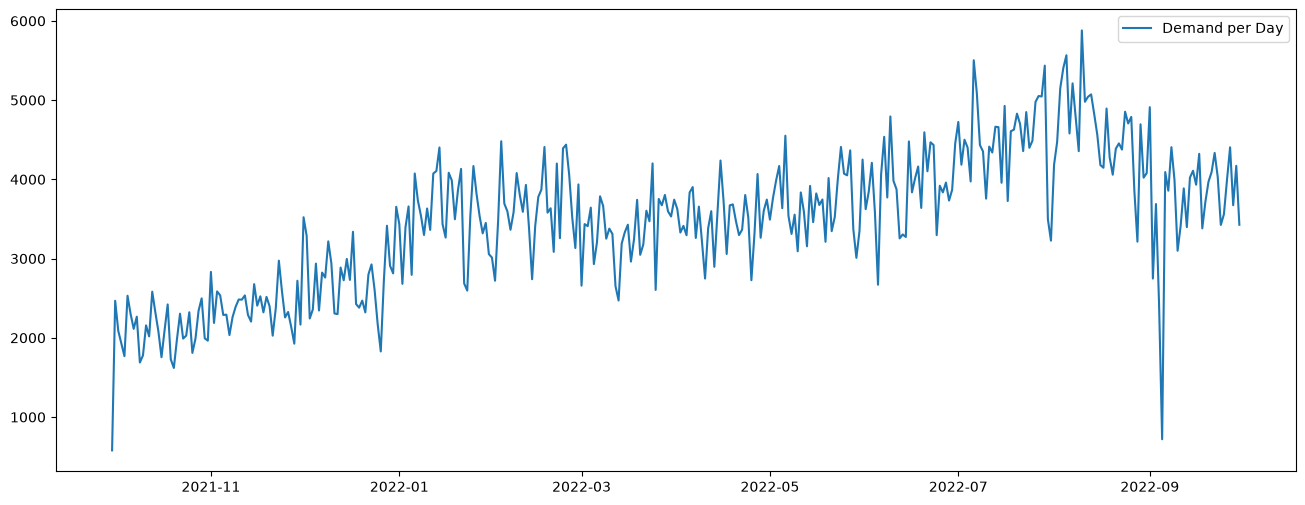

In [177]:
plt.figure(figsize=(16,6))
plt.plot(df_.index,df_.values,linewidth=1.5,label='Demand per Day')
plt.legend()
plt.show()

-- In the beginning (30/09/2021), Demand of EV chargering was somewhere near 2000, then by time, it showed a postivie upward growth. 
in one year, Avg demand of EV charging reached to 4500 - 5000. which is almost double of the Demand, we have in starting(30/09/2021)

-- Data do have a lot of noise, nd if we look at the data, we can see during winters, data shows the higher demand of EV charging, as during Oct 2022, Demand reached to around 5500 - 6000.

-- Another important insight, we have in our data is, in Sept, EV demand dropped to zero. maybe it can be the data mis entry or some other reason. as it dropped to zero. then next day it again started following its pattern or trend.